In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('../raw_laps.csv')
print(df.shape)
print(df['GP'].unique())
df.head()

(3798, 14)
<ArrowStringArray>
['Spain', 'Monaco', 'Great Britain']
Length: 3, dtype: str


,Unnamed: 0,Driver,LapNumber,LapTime,Stint,Compound,TyreLife,PitInTime,PitOutTime,TrackStatus,IsAccurate,Year,GP,LapTimeSeconds
0,0,VER,1.0,0 days 00:01:23.935000,1.0,MEDIUM,1.0,NaN,NaN,1,False,2023,Spain,83.935
1,1,VER,2.0,0 days 00:01:20.402000,1.0,MEDIUM,2.0,NaN,NaN,1,True,2023,Spain,80.402
2,2,VER,3.0,0 days 00:01:20.499000,1.0,MEDIUM,3.0,NaN,NaN,1,True,2023,Spain,80.499
3,3,VER,4.0,0 days 00:01:20.346000,1.0,MEDIUM,4.0,NaN,NaN,1,True,2023,Spain,80.346
4,4,VER,5.0,0 days 00:01:20.283000,1.0,MEDIUM,5.0,NaN,NaN,1,True,2023,Spain,80.283


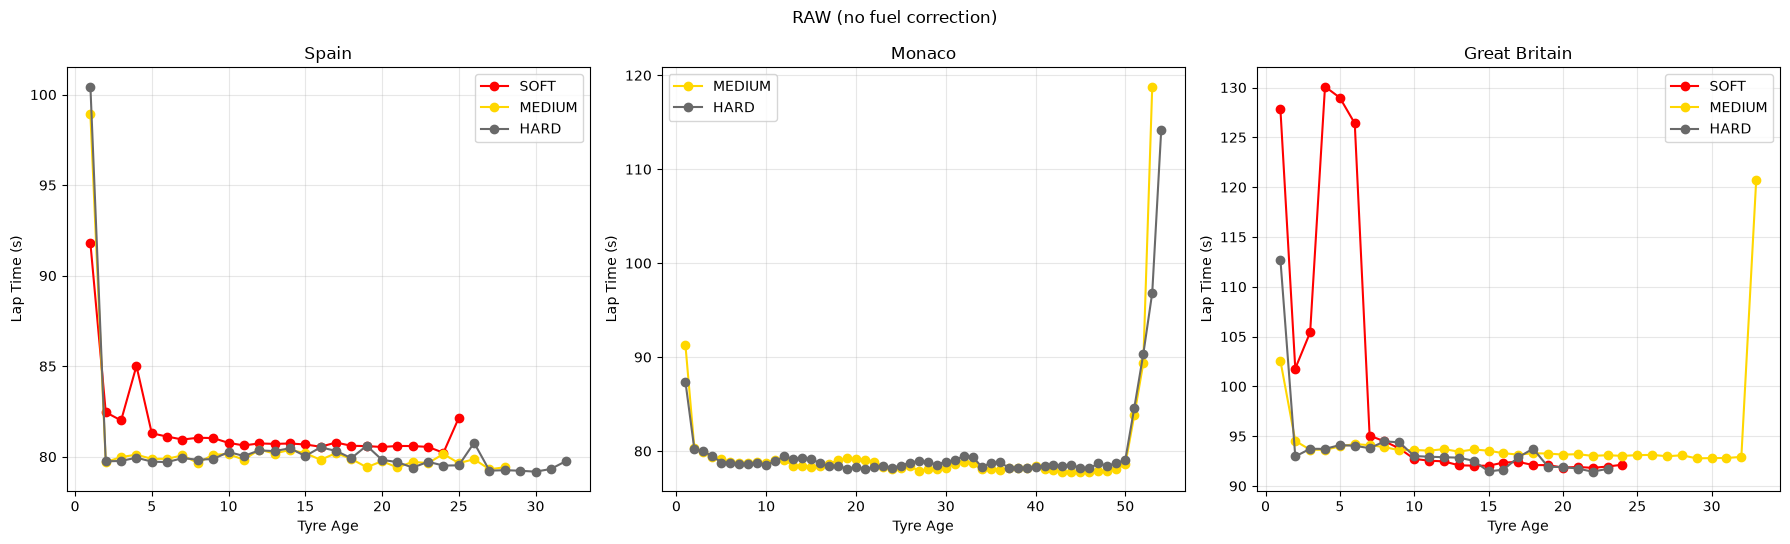

In [2]:
# Plot WITHOUT fuel correction — raw fuel-adjusted removed, just LapTimeSeconds
races = ['Spain', 'Monaco', 'Great Britain']
compounds = ['SOFT', 'MEDIUM', 'HARD']
colors = {'SOFT': 'red', 'MEDIUM': 'gold', 'HARD': 'dimgray'}

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
for ax, race in zip(axes, races):
    race_df = df[df['GP'] == race]
    for comp in compounds:
        sub = race_df[race_df['Compound'] == comp]
        if sub.empty: continue
        counts = sub.groupby('TyreLife').size()
        curve = sub.groupby('TyreLife')['LapTimeSeconds'].median()   # RAW, no fuel adj
        curve = curve[counts >= 3]
        if len(curve) < 2: continue
        ax.plot(curve.index, curve.values, marker='o', color=colors[comp], label=comp)
    ax.set_title(race); ax.set_xlabel('Tyre Age'); ax.set_ylabel('Lap Time (s)')
    ax.grid(alpha=0.3); ax.legend()
plt.suptitle('RAW (no fuel correction)'); plt.tight_layout(); plt.show()

## Fuel-corrected degradation

The plot above is measuring the wrong thing. Raw lap time is

```
lap time = baseline + tyre degradation - fuel burn - track evolution
```

and over a stint the car sheds ~1.7 kg/lap, worth roughly **-0.055 s/lap** — more
than the tyre loses. So raw times fall as the tyre ages. Two fixes below:

1. **Estimate race progress and remove it.** Fit `lap time ~ driver + LapNumber +
   TyreLife x Compound` per circuit. The `LapNumber` coefficient is the combined
   fuel + track-evolution effect; subtracting it leaves the tyre effect.
2. **Don't pool tyre ages naively.** High tyre age only occurs late in the race and
   only for drivers on long stints, so the right-hand side of the x-axis is
   systematically lighter on fuel and thinner on drivers. Correcting for fuel handles
   the first; a per-driver baseline and a minimum-sample rule handle the second.

Also note the cells above read `raw_laps.csv` — in/out laps and safety-car laps are
still in it. This section uses `clean_laps.csv`, the output of `clean.py`.

In [3]:
import numpy as np

DRY = ['SOFT', 'MEDIUM', 'HARD']
RACES = ['Spain', 'Monaco', 'Great Britain']
MIN_LAPS, MIN_DRIVERS = 3, 3      # a tyre-age point needs real support to be plotted

clean = pd.read_csv('../clean_laps.csv')
clean = clean[clean.Compound.isin(DRY)].copy()   # wets/inters measure a drying track


def race_progress_coef(x):
    """s/lap from fuel burn + track evolution, fitted jointly with degradation
    so the two aren't confounded. Driver dummies absorb raw pace differences."""
    X = pd.get_dummies(x['Driver'], prefix='d').astype(float)
    X['LapNumber'] = x.LapNumber.values
    for c in DRY:
        X['age_' + c] = np.where(x.Compound.values == c, x.TyreLife.values, 0.0)
    X = X.loc[:, X.std() > 0]
    beta, *_ = np.linalg.lstsq(X.values, x.LapTimeSeconds.values, rcond=None)
    return dict(zip(X.columns, beta))


fuel, deg_model, parts = {}, [], []
for gp in RACES:
    x = clean[clean.GP == gp].copy()
    co = race_progress_coef(x)
    fuel[gp] = co['LapNumber']
    deg_model += [{'GP': gp, 'Compound': c, 'model_slope': round(co['age_' + c], 3)}
                  for c in DRY if 'age_' + c in co]

    x['Corrected'] = x.LapTimeSeconds - co['LapNumber'] * x.LapNumber
    # common per-driver baseline, so pooling ages across drivers is fair
    x['Corrected'] += x.Corrected.median() - x.groupby('Driver')['Corrected'].transform('median')
    parts.append(x)

clean = pd.concat(parts, ignore_index=True)

print('race-progress (fuel + track evolution), s/lap:')
for gp, b in fuel.items():
    print(f'  {gp:15s} {b:+.3f}')
pd.DataFrame(deg_model).pivot(index='GP', columns='Compound', values='model_slope')[DRY]

race-progress (fuel + track evolution), s/lap:
  Spain           -0.056
  Monaco          -0.050
  Great Britain   -0.054


Compound,SOFT,MEDIUM,HARD
GP,,,
Great Britain,0.023,0.022,0.022
Monaco,0.091,0.027,0.037
Spain,0.058,0.055,0.049


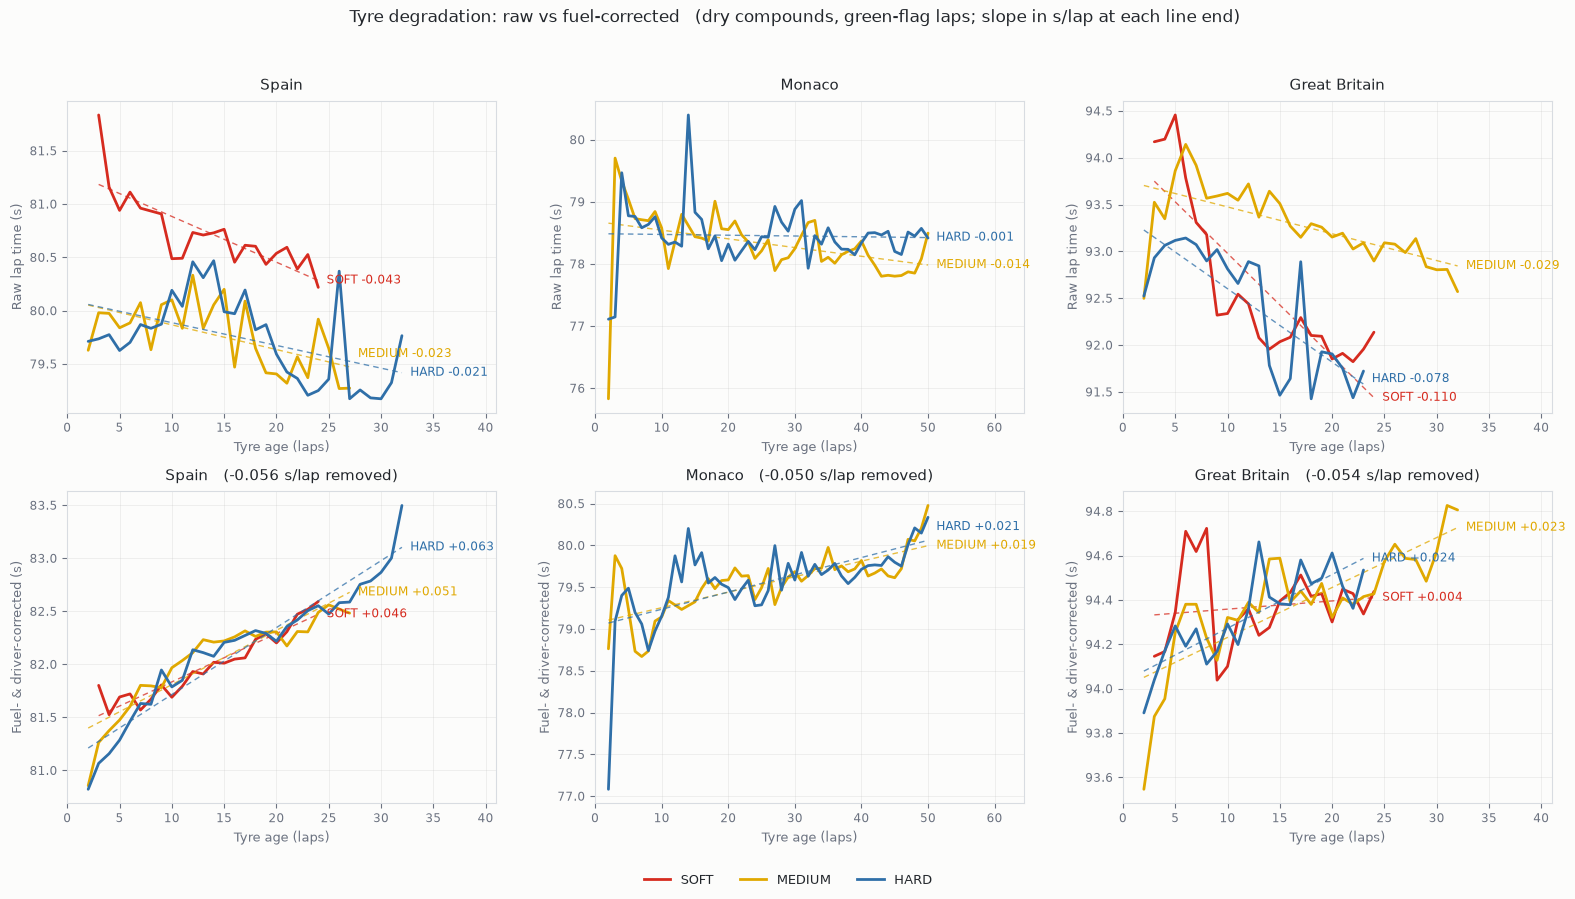

view                      raw  corrected
GP            Compound                  
Great Britain HARD     -0.078      0.024
              MEDIUM   -0.029      0.023
              SOFT     -0.110      0.004
Monaco        HARD     -0.001      0.021
              MEDIUM   -0.014      0.019
Spain         HARD     -0.021      0.063
              MEDIUM   -0.023      0.051
              SOFT     -0.043      0.046

In [4]:
# Palette: SOFT/MEDIUM keep the F1 red/amber; HARD moves off grey (a pure neutral
# reads as "no series"). Checked for colour-vision deficiency: worst adjacent pair
# is MEDIUM/SOFT at deltaE 19.2 (deuteranopia). Amber is under 3:1 on white, so every
# line is directly labelled and the slopes are printed as a table below.
COLORS = {'SOFT': '#D62B1F', 'MEDIUM': '#E0A800', 'HARD': '#2F6FA8'}
SURFACE, INK, MUTED = '#FCFCFB', '#22262B', '#6B7280'


def age_curve(sub, col):
    """Median lap time per tyre age, kept only where the sample is real."""
    g = sub.groupby('TyreLife').agg(v=(col, 'median'), n=(col, 'size'),
                                    d=('Driver', 'nunique'))
    return g[(g.n >= MIN_LAPS) & (g.d >= MIN_DRIVERS)]['v']


def place_labels(ax, anchors):
    """Direct-label each line at its right end, nudged apart so they never overlap."""
    lo, hi = ax.get_ylim()
    gap = (hi - lo) * 0.06
    anchors.sort(key=lambda a: a[1])
    for i in range(1, len(anchors)):
        anchors[i][1] = max(anchors[i][1], anchors[i - 1][1] + gap)
    for x, y, text, color in anchors:
        ax.annotate(text, (x, y), xytext=(6, 0), textcoords='offset points',
                    va='center', fontsize=8.5, color=color)


fig, axes = plt.subplots(2, 3, figsize=(16, 9), facecolor=SURFACE)
rows = [('LapTimeSeconds', 'Raw lap time (s)'),
        ('Corrected', 'Fuel- & driver-corrected (s)')]
slopes = []

for (col, ylab), axrow in zip(rows, axes):
    for ax, gp in zip(axrow, RACES):
        ax.set_facecolor(SURFACE)
        race_df = clean[clean.GP == gp]
        anchors = []
        for comp in DRY:
            c = age_curve(race_df[race_df.Compound == comp], col)
            if len(c) < 5:
                continue
            fit = np.polyfit(c.index, c.values, 1)
            xs = np.array([c.index.min(), c.index.max()])
            ax.plot(c.index, c.values, lw=2, color=COLORS[comp], solid_capstyle='round')
            ax.plot(xs, np.polyval(fit, xs), lw=1, ls=(0, (4, 3)),
                    color=COLORS[comp], alpha=0.75)
            # anchor on the fitted end, not the noisy last point
            anchors.append([xs[-1], float(np.polyval(fit, xs[-1])),
                            f'{comp} {fit[0]:+.3f}', COLORS[comp]])
            slopes.append({'GP': gp, 'Compound': comp,
                           'view': 'raw' if col == 'LapTimeSeconds' else 'corrected',
                           's_per_lap': round(fit[0], 3)})

        ax.set_title(gp if col == 'LapTimeSeconds' else
                     f'{gp}   ({fuel[gp]:+.3f} s/lap removed)',
                     fontsize=10.5, color=INK, pad=8)
        ax.set_xlabel('Tyre age (laps)', fontsize=9, color=MUTED)
        ax.set_ylabel(ylab, fontsize=9, color=MUTED)
        ax.grid(alpha=0.18, lw=0.7)
        ax.margins(x=0.30)
        ax.set_xlim(left=0)          # negative tyre age is meaningless
        ax.tick_params(colors=MUTED, labelsize=8.5)
        for s in ax.spines.values():
            s.set_color('#D8DCE1')
        place_labels(ax, anchors)

fig.legend(handles=[plt.Line2D([], [], color=COLORS[c], lw=2, label=c) for c in DRY],
           loc='lower center', ncol=3, frameon=False, fontsize=9.5, labelcolor=INK)
fig.suptitle('Tyre degradation: raw vs fuel-corrected   '
             '(dry compounds, green-flag laps; slope in s/lap at each line end)',
             fontsize=12, color=INK, y=0.985)
fig.tight_layout(rect=[0, 0.04, 1, 0.96])
fig.savefig('../report/degradation_fuel_corrected.png', dpi=130, facecolor=SURFACE)
plt.show()

pd.DataFrame(slopes).pivot_table(index=['GP', 'Compound'],
                                 columns='view', values='s_per_lap')[['raw', 'corrected']]

## Stage 3 deliverable — degradation rates

The plot above shows degradation exists. To *quantify* it we need a coefficient, and
the first specification tried gives physically impossible answers. Both are kept
below, because the failure is the informative part.

**Spec A** — `LapTime ~ 1 + LapNumber + TyreLife`, fit per circuit **per compound**.
Under-identified. Within a stint `LapNumber` and `TyreLife` both increment by 1 every
lap, so they are collinear; the only thing that decorrelates them is *several stints
with different pit laps*, where tyre age resets while race lap keeps climbing. Inside
a single compound there may be almost no such variation — Monaco SOFT is one stint by
one driver at correlation exactly 1.000, a singular design matrix. The fit can then
split variance between the two coefficients arbitrarily, which is where
`b_fuel = +3.3 s/lap` comes from. That is a degenerate fit, not a finding.

**Spec B** — one shared `b_fuel` per circuit, driver fixed effects, compound-specific
`TyreLife`. Fuel burn is a property of the *car*, not the tyre: there is no reason a
hard compound would burn fuel differently, and estimating it per compound discards the
cross-stint variation that identifies it. Pooling compounds restores that variation.

The diagnostic that Spec B is identified: its three `b_fuel` estimates collapse onto
about −0.05 s/lap, the known physical value (~1.7 kg/lap × ~0.03 s/kg), rather than
scattering from −0.039 to −0.093.

A compound is reported only where it has at least `MIN_STINTS` distinct stints — a
criterion fixed before looking at the answers, which excludes Monaco SOFT as
unidentified rather than as inconvenient.

In [5]:
MIN_STINTS = 5      # fewer than this and b_fuel/b_deg are not separately identified


def ols(X, y):
    """Coefficients and their standard errors."""
    beta, *_ = np.linalg.lstsq(X, y, rcond=None)
    resid = y - X @ beta
    dof = len(y) - np.linalg.matrix_rank(X)
    cov = (resid @ resid / dof) * np.linalg.pinv(X.T @ X)
    return beta, np.sqrt(np.diag(cov))


# ---- Spec A: per circuit per compound (kept to show why it fails) ----------
spec_a = []
for gp in RACES:
    for comp in DRY:
        s = clean[(clean.GP == gp) & (clean.Compound == comp)]
        n_stints = s.groupby(['Driver', 'Stint']).ngroups
        if len(s) < 20:
            continue
        X = np.column_stack([np.ones(len(s)), s.LapNumber, s.TyreLife])
        b, se = ols(X, s.LapTimeSeconds.values)
        spec_a.append({'GP': gp, 'Compound': comp, 'laps': len(s), 'stints': n_stints,
                       'corr': round(np.corrcoef(s.LapNumber, s.TyreLife)[0, 1], 3),
                       'b_fuel': round(b[1], 3), 'b_deg': round(b[2], 3)})
spec_a = pd.DataFrame(spec_a)

# ---- Spec B: per circuit, shared fuel + driver fixed effects ---------------
spec_b, b_fuel = [], {}
for gp in RACES:
    x = clean[clean.GP == gp]
    M = pd.get_dummies(x.Driver, prefix='d').astype(float)
    M['LapNumber'] = x.LapNumber.values
    for c in DRY:
        M['age_' + c] = np.where(x.Compound.values == c, x.TyreLife.values, 0.0)
    M = M.loc[:, M.std() > 0]
    b, se = ols(M.values, x.LapTimeSeconds.values)
    co = dict(zip(M.columns, zip(b, se)))
    b_fuel[gp] = co['LapNumber'][0]
    for c in DRY:
        n_stints = x[x.Compound == c].groupby(['Driver', 'Stint']).ngroups
        if 'age_' + c not in co or n_stints < MIN_STINTS:
            continue                       # unidentified: too few stints to fit
        spec_b.append({'GP': gp, 'Compound': c, 'stints': n_stints,
                       'b_deg': round(co['age_' + c][0], 3),
                       'se': round(co['age_' + c][1], 3)})
spec_b = pd.DataFrame(spec_b)

print('SPEC A - b_fuel should be ~-0.05 everywhere; it is not:')
print(spec_a.to_string(index=False))
print(f"\n  spread of b_fuel: {spec_a.b_fuel.min():+.3f} to {spec_a.b_fuel.max():+.3f}")
print('\nSPEC B - one shared fuel coefficient per circuit:')
for gp, v in b_fuel.items():
    print(f'  {gp:15s} b_fuel {v:+.3f}')
print(f"  spread: {min(b_fuel.values()):+.3f} to {max(b_fuel.values()):+.3f}  <- identified")

excluded = [(gp, c) for gp in RACES for c in DRY
            if not ((spec_b.GP == gp) & (spec_b.Compound == c)).any()]
print(f'\nexcluded for < {MIN_STINTS} stints: {excluded}')

# Stage 3 deliverable: degradation rate per compound per circuit
deg_rates = spec_b.pivot(index='GP', columns='Compound', values='b_deg')
deg_rates = deg_rates.reindex(index=RACES, columns=DRY)
deg_rates

SPEC A - b_fuel should be ~-0.05 everywhere; it is not:
           GP Compound  laps  stints  corr  b_fuel  b_deg
        Spain     SOFT   298      23 0.264  -0.063  0.044
        Spain   MEDIUM   353      17 0.510  -0.047  0.042
        Spain     HARD   491      22 0.556  -0.057  0.044
       Monaco     SOFT    26       1 1.000   3.322 -3.172
       Monaco   MEDIUM   293      12 0.647  -0.061  0.029
       Monaco     HARD   534      16 0.811  -0.039  0.029
Great Britain     SOFT   237      17 0.396  -0.051  0.001
Great Britain   MEDIUM   410      18 0.670  -0.056  0.019
Great Britain     HARD   112       8 0.463  -0.093  0.050

  spread of b_fuel: -0.093 to +3.322

SPEC B - one shared fuel coefficient per circuit:
  Spain           b_fuel -0.056
  Monaco          b_fuel -0.050
  Great Britain   b_fuel -0.054
  spread: -0.056 to -0.050  <- identified

excluded for < 5 stints: [('Monaco', 'SOFT')]


Compound,SOFT,MEDIUM,HARD
GP,,,
Spain,0.058,0.055,0.049
Monaco,NaN,0.027,0.037
Great Britain,0.023,0.022,0.022


---
# Stage 4 — Optimal pit window

A stop trades a **fixed cost now** (pit loss) against a **recurring gain later**
(fresh rubber instead of worn). Model the time a strategy loses relative to a
hypothetical car that never stops and never degrades:

```
cost(strategy) = n_stops x pit_loss  +  sum over stints [ base_c x L + deg_c x L(L+1)/2 ]
```

The `L(L+1)/2` is the running total of degradation over a stint of `L` laps: lap 1 on
that set loses `deg_c`, lap 2 loses `2 x deg_c`, and so on. Quadratic growth in stint
length against linear growth in pit stops is the whole trade — it is why there is an
interior optimum at all.

Fuel is deliberately absent. It burns off at the same rate whichever lap you stop on,
so it shifts every strategy's total by the same amount and cannot move the ranking.
Leaving it out keeps the comparison clean.

Three inputs, each estimated from the data below:

1. **`pit_loss`** per circuit — from actual green-flag stops.
2. **`deg_c`** per compound per circuit — Stage 3's `deg_rates`.
3. **`base_c`**, fresh-tyre pace offset per compound — measured, and, as it turns out,
   not distinguishable from zero.

In [6]:
# --- Input 1: pit loss, estimated from real stops -------------------------
# Cost of a stop = (in-lap + out-lap) - 2 x what those laps would have taken at
# normal pace. Both halves must be summed: the split between them is an artefact of
# where pit entry/exit sits relative to the start/finish line, which differs per
# circuit (Silverstone's in-lap delta is ~0s and Monaco's is ~18s), but the total is
# the physically meaningful quantity.
#
# Green-flag stops only. A stop under safety car is much cheaper because the whole
# field is slowed, and including those would understate the real cost of stopping.

raw_all = pd.read_csv('../raw_laps.csv')                 # untouched: race distance
raw_all = raw_all[raw_all.LapTimeSeconds.notna()].copy()
raw_all['TrackStatus'] = raw_all.TrackStatus.astype(str)
raw_all['is_in'] = raw_all.PitInTime.notna()
raw_all['is_out'] = raw_all.PitOutTime.notna()

# Rain-free subset, used ONLY to price a stop. Monaco's last laps are a drying
# track, where an "in-lap delta" measures the weather rather than the pit lane.
raw = raw_all[~((raw_all.GP == 'Monaco') & (raw_all.LapNumber >= 51))]

REF_WINDOW = 6
normal = raw[~raw.is_in & ~raw.is_out & (raw.TrackStatus == '1') & (raw.LapNumber > 2)]

stops = []
for (gp, drv), g in raw.groupby(['GP', 'Driver']):
    pool = normal[(normal.GP == gp) & (normal.Driver == drv)]
    for _, inlap in g[g.is_in].iterrows():
        out = g[(g.LapNumber == inlap.LapNumber + 1) & g.is_out]
        if out.empty or inlap.TrackStatus != '1' or out.iloc[0].TrackStatus != '1':
            continue
        out = out.iloc[0]
        near = pool[pool.LapNumber.between(inlap.LapNumber - REF_WINDOW,
                                           inlap.LapNumber + REF_WINDOW + 1)]
        if len(near) < 4:
            continue
        ref = near.LapTimeSeconds.median()
        stops.append({'GP': gp, 'Driver': drv, 'lap': inlap.LapNumber,
                      'loss': (inlap.LapTimeSeconds - ref) + (out.LapTimeSeconds - ref)})

stops = pd.DataFrame(stops)
pit_loss = stops.groupby('GP')['loss'].median()          # median: robust to traffic

# Race distance and real stop laps come from the UNFILTERED data. Taking them from
# the rain-free subset would turn Monaco into a 50-lap race and discard the stops
# that actually happened.
race_laps = raw_all.groupby('GP').LapNumber.max().astype(int)
actual_stops = (raw_all[raw_all.is_in]
                .groupby(['GP', 'Driver'])['LapNumber']
                .apply(lambda s: sorted(int(v) for v in s)))

print('pit loss (s), green-flag stops only:')
print(stops.groupby('GP')['loss'].agg(['count', 'median', 'std']).round(2).to_string())
print('\nrace length (laps):')
print(race_laps.to_string())

pit loss (s), green-flag stops only:
               count  median   std
GP                                
Great Britain     10   19.83  4.69
Monaco             9   19.98  3.71
Spain             43   23.83  3.67

race length (laps):
GP
Great Britain    52
Monaco           78
Spain            66


In [7]:
# --- Inputs 2 and 3: degradation rate and fresh-tyre pace, per compound ----
# Spec B extended with compound intercepts (HARD as reference), so each compound gets
# both a starting pace offset and a wear rate. Same identification logic as Stage 3:
# one shared fuel term, driver fixed effects, compounds with >= MIN_STINTS stints.

REF_COMPOUND = 'HARD'
params = {}

for gp in RACES:
    x = clean[clean.GP == gp]
    n_stints = {c: x[x.Compound == c].groupby(['Driver', 'Stint']).ngroups for c in DRY}
    fitted = [c for c in DRY if n_stints[c] >= MIN_STINTS]

    M = pd.get_dummies(x.Driver, prefix='d').astype(float)
    M['LapNumber'] = x.LapNumber.values
    for c in fitted:
        if c != REF_COMPOUND:
            M['base_' + c] = (x.Compound.values == c).astype(float)
        M['age_' + c] = np.where(x.Compound.values == c, x.TyreLife.values, 0.0)
    M = M.loc[:, M.std() > 0]
    b, se = ols(M.values, x.LapTimeSeconds.values)
    co = dict(zip(M.columns, zip(b, se)))

    params[gp] = {c: {'deg': co['age_' + c][0], 'deg_se': co['age_' + c][1],
                      'base': co.get('base_' + c, (0.0, 0.0))[0],
                      'base_se': co.get('base_' + c, (0.0, 0.0))[1]}
                  for c in fitted}

rows = [{'GP': gp, 'Compound': c, 'base': round(v['base'], 3),
         'base_se': round(v['base_se'], 3), 'deg': round(v['deg'], 3),
         'deg_se': round(v['deg_se'], 3)}
        for gp, cs in params.items() for c, v in cs.items()]
pace = pd.DataFrame(rows)
print(f'fresh-tyre pace offsets, seconds vs {REF_COMPOUND}:')
print(pace.to_string(index=False))

sig = pace[pace.base_se > 0]
print(f'\nlargest |base| / se across all compounds: '
      f'{(sig.base.abs() / sig.base_se).max():.1f}')
print('A soft should be several tenths a lap quicker than a hard on fresh rubber.')
print('Nothing here clears ~2 standard errors, and Spain SOFT even comes out slower,')
print('so these offsets are set to zero below and flagged as a limitation.')

for gp in params:                      # not measurable -> do not pretend otherwise
    for c in params[gp]:
        params[gp][c]['base'] = 0.0

fresh-tyre pace offsets, seconds vs HARD:
           GP Compound   base  base_se   deg  deg_se
        Spain     SOFT  0.099    0.081 0.052   0.005
        Spain   MEDIUM -0.050    0.073 0.058   0.004
        Spain     HARD  0.000    0.000 0.049   0.003
       Monaco   MEDIUM  0.196    0.121 0.014   0.005
       Monaco     HARD  0.000    0.000 0.030   0.004
Great Britain     SOFT -0.023    0.102 0.024   0.005
Great Britain   MEDIUM  0.008    0.086 0.022   0.003
Great Britain     HARD  0.000    0.000 0.022   0.005

largest |base| / se across all compounds: 1.6
A soft should be several tenths a lap quicker than a hard on fresh rubber.
Nothing here clears ~2 standard errors, and Spain SOFT even comes out slower,
so these offsets are set to zero below and flagged as a limitation.


In [8]:
# --- The optimiser ---------------------------------------------------------
from itertools import product

MIN_STINT = 8        # nobody runs a 3-lap stint; keeps the search realistic


def strategy_cost(lengths, compounds, gp, pit=None):
    """Seconds lost vs a car that never stops and never degrades.

    base * L would let a compound's raw pace offset dominate the comparison --
    this optimises "fewest seconds lost to stops and wear", not "fastest
    possible race", and those give different answers when base != 0. It is
    inert right now only because base was zeroed above (undetectable at
    p < 0.05), so this stays pure degradation-vs-pit-loss by accident of the
    data, not by construction. Re-enabling base later needs this noted.
    """
    p = params[gp]
    cost = (pit_loss[gp] if pit is None else pit) * (len(lengths) - 1)
    for L, c in zip(lengths, compounds):
        cost += p[c]['base'] * L + p[c]['deg'] * L * (L + 1) / 2
    return cost


def best_strategy(gp, n_stops):
    """Cheapest stint lengths + compounds for a given number of stops.

    F1 requires at least two different dry compounds in a dry race, so
    single-compound plans are excluded.
    """
    N, avail = race_laps[gp], list(params[gp])
    best = None
    for splits in product(range(MIN_STINT, N - MIN_STINT + 1), repeat=n_stops):
        if list(splits) != sorted(splits):
            continue                                  # stop laps must increase
        bounds = [0, *splits, N]
        lengths = [b - a for a, b in zip(bounds, bounds[1:])]
        if min(lengths) < MIN_STINT:
            continue
        for combo in product(avail, repeat=n_stops + 1):
            if len(set(combo)) < 2:
                continue                              # two-compound rule
            c = strategy_cost(lengths, combo, gp)
            if best is None or c < best['cost']:
                best = {'stops': list(splits), 'compounds': list(combo),
                        'lengths': lengths, 'cost': c}
    return best


# longest stint actually observed per compound: anything beyond this is extrapolation
observed_max = (clean.groupby(['GP', 'Compound', 'Driver', 'Stint']).TyreLife.max()
                     .groupby(['GP', 'Compound']).max())

rows = []
for gp in RACES:
    counts = actual_stops[gp].apply(len).value_counts()
    plans = {n: best_strategy(gp, n) for n in (1, 2)}
    win = min(plans, key=lambda n: plans[n]['cost'])

    for n, b in plans.items():
        same = [s for s in actual_stops[gp] if len(s) == n]
        med = [int(np.median([s[i] for s in same])) for i in range(n)] if same else []
        # Per stint against ITS OWN compound's cap, not the strategy's longest
        # stint against the max cap of any compound it uses. The bug in the
        # latter: Spain's 1-stop plan runs 32 laps on SOFT, but the longest
        # SOFT stint ever seen at Spain is 27 -- checking 32 against
        # max(SOFT=27, HARD=50)=50 would miss that entirely.
        over_cap = [L > observed_max.get((gp, c), 0)
                    for L, c in zip(b['lengths'], b['compounds'])]
        rows.append({'GP': gp, 'n_stops': n, 'model_stops': str(b['stops']),
                     'compounds': '-'.join(x[0] for x in b['compounds']),
                     'cost_s': round(b['cost'], 1), 'drivers': int(counts.get(n, 0)),
                     'actual_median': str(med) if med else '-',
                     'model_pick': n == win,
                     'extrapolates': any(over_cap)})

    # Pit loss enters the cost as n_stops x pit_loss, and for a FIXED stop count it
    # does not move the optimal split. So deg_k = cost_k - k x pit_loss is a constant,
    # and 1-stop beats 2-stop exactly when pit_loss > deg_1 - deg_2. No search needed.
    d1 = plans[1]['cost'] - 1 * pit_loss[gp]
    d2 = plans[2]['cost'] - 2 * pit_loss[gp]
    print(f"{gp:15s} model prefers {win}-stop by {abs(plans[1]['cost']-plans[2]['cost']):5.1f}s"
          f"  |  break-even pit loss {d1 - d2:5.1f}s vs estimated {pit_loss[gp]:.1f}s")

pit_window = pd.DataFrame(rows)
print('\nlongest stint observed per compound (laps):')
print(observed_max.astype(int).to_string())
pit_window

Spain           model prefers 1-stop by   5.3s  |  break-even pit loss  18.6s vs estimated 23.8s
Monaco          model prefers 1-stop by   8.1s  |  break-even pit loss  11.9s vs estimated 20.0s
Great Britain   model prefers 1-stop by  14.9s  |  break-even pit loss   5.0s vs estimated 19.8s

longest stint observed per compound (laps):
GP             Compound
Great Britain  HARD        31
               MEDIUM      32
               SOFT        30
Monaco         HARD        51
               MEDIUM      50
               SOFT        27
Spain          HARD        50
               MEDIUM      32
               SOFT        27


,GP,n_stops,model_stops,compounds,cost_s,drivers,actual_median,model_pick,extrapolates
0,Spain,1,[32],S-H,80.3,0,-,True,True
1,Spain,2,"[22, 43]",H-S-H,85.6,17,"[16, 39]",False,False
2,Monaco,1,[25],H-M,50.0,7,[53],True,True
3,Monaco,2,"[15, 46]",H-M-M,58.0,9,"[33, 54]",False,False
4,Great Britain,1,[26],M-H,35.2,14,[31],True,False
5,Great Britain,2,"[17, 34]",M-H-M,50.1,4,"[16, 32]",False,False


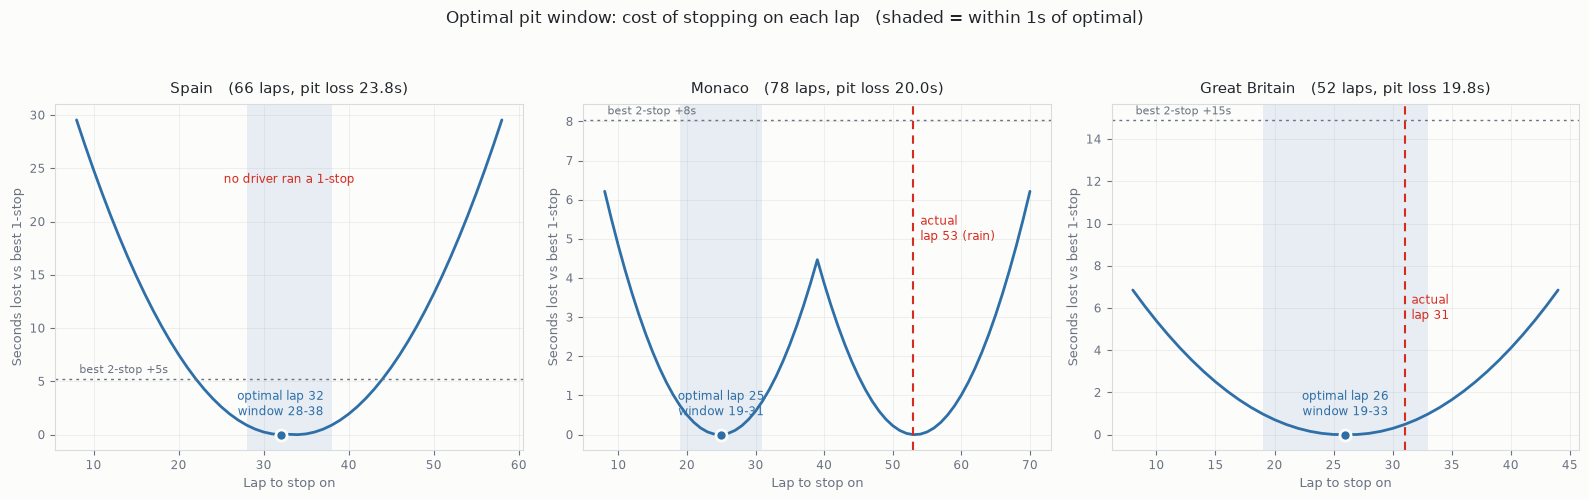

In [9]:
# --- The pit window --------------------------------------------------------
# Cost of a 1-stop as a function of which lap you stop on. The shape is the point:
# a sharp minimum means the stop lap matters, a flat basin means it barely does.

WINDOW_S = 1.0        # "within a second of optimal" defines the usable window
CURVE, ACTUAL, NEUTRAL = '#2F6FA8', '#D62B1F', '#6B7280'


def one_stop_curve(gp):
    """Best achievable 1-stop cost for every legal stop lap."""
    N, avail = race_laps[gp], list(params[gp])
    laps = np.array(range(MIN_STINT, N - MIN_STINT + 1))
    costs = np.array([min(strategy_cost([L, N - L], combo, gp)
                          for combo in product(avail, repeat=2) if len(set(combo)) == 2)
                      for L in laps])
    return laps, costs


fig, axes = plt.subplots(1, 3, figsize=(16, 5), facecolor=SURFACE)

for ax, gp in zip(axes, RACES):
    laps, costs = one_stop_curve(gp)
    best_i = int(np.argmin(costs))
    rel = costs - costs[best_i]
    # Contiguous basin around the optimum. Monaco's curve has TWO minima -- stop
    # early or stop late both work -- so taking min/max of every qualifying lap
    # would span the hump between them and report a window that isn't one.
    ok = rel <= WINDOW_S
    lo_i = hi_i = best_i
    while lo_i > 0 and ok[lo_i - 1]:
        lo_i -= 1
    while hi_i < len(ok) - 1 and ok[hi_i + 1]:
        hi_i += 1
    inside = laps[lo_i:hi_i + 1]
    two_stop_rel = pit_window.query('GP == @gp and n_stops == 2').cost_s.iloc[0] - costs[best_i]

    ax.set_facecolor(SURFACE)
    ax.axvspan(inside.min(), inside.max(), color=CURVE, alpha=0.10, lw=0)
    ax.plot(laps, rel, lw=2, color=CURVE, solid_capstyle='round')
    ax.plot(laps[best_i], 0, 'o', ms=8, color=CURVE,
            markeredgecolor=SURFACE, markeredgewidth=2, zorder=5)
    ax.annotate(f'optimal lap {laps[best_i]}\nwindow {inside.min()}-{inside.max()}',
                (laps[best_i], 0), xytext=(0, 14), textcoords='offset points',
                ha='center', fontsize=8.5, color=CURVE)

    same = [s for s in actual_stops[gp] if len(s) == 1]
    if same:
        a = int(np.median([s[0] for s in same]))
        # Monaco's 1-stoppers didn't choose lap 53 on tyre grounds: that is the
        # switch to wets when the rain arrived, so it is not a strategy comparison.
        note = 'actual\nlap {} {}'.format(a, '(rain)' if gp == 'Monaco' else '')
        ax.axvline(a, color=ACTUAL, lw=1.5, ls=(0, (4, 3)))
        ax.annotate(note, (a, rel.max() * 0.80), xytext=(5, 0),
                    textcoords='offset points', fontsize=8.5, color=ACTUAL)
    else:
        ax.annotate('no driver ran a 1-stop', (laps[len(laps) // 2], rel.max() * 0.80),
                    ha='center', fontsize=8.5, color=ACTUAL)

    ax.axhline(two_stop_rel, color=NEUTRAL, lw=1, ls=(0, (2, 3)))
    ax.annotate(f'best 2-stop {two_stop_rel:+.0f}s', (laps[0], two_stop_rel),
                xytext=(2, 4), textcoords='offset points', fontsize=8, color=NEUTRAL)

    ax.set_title(f'{gp}   ({race_laps[gp]} laps, pit loss {pit_loss[gp]:.1f}s)',
                 fontsize=10.5, color=INK, pad=8)
    ax.set_xlabel('Lap to stop on', fontsize=9, color=MUTED)
    ax.set_ylabel('Seconds lost vs best 1-stop', fontsize=9, color=MUTED)
    ax.grid(alpha=0.18, lw=0.7)
    ax.tick_params(colors=MUTED, labelsize=8.5)
    for s in ax.spines.values():
        s.set_color('#D8DCE1')

fig.suptitle('Optimal pit window: cost of stopping on each lap   '
             f'(shaded = within {WINDOW_S:.0f}s of optimal)',
             fontsize=12, color=INK, y=0.99)
fig.tight_layout(rect=[0, 0, 1, 0.94])
fig.savefig('../report/pit_window.png', dpi=130, facecolor=SURFACE)
plt.show()
